In [20]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.data_loader import load_data
from src.config import DATA_PATH, TARGET_COLUMN

In [21]:
# Load the data
df = load_data(DATA_PATH)
print("Data loaded successfully. It contains ", df.shape[0], " rows and ", df.shape[1], " columns.")

Data loaded successfully from c:\Users\mainl\OneDrive\Documents\PortfolioProjects\telco-customer-churn\data\customer_churn_data.csv.
Data loaded successfully. It contains  7043  rows and  21  columns.


In [22]:
# Display the first few rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
#Check for missing values in all columns
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [24]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
# Convert 'TotalCharges' to numeric, forcing errors to NaN, and check for missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values in TotalCharges: ", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges:  11


In [26]:
# Display rows with missing 'TotalCharges'
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [27]:
# Display summary statistics
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


In [28]:
# Churn distribution
print("Churn distribution: ", df[TARGET_COLUMN].value_counts(normalize=True))

Churn distribution:  Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


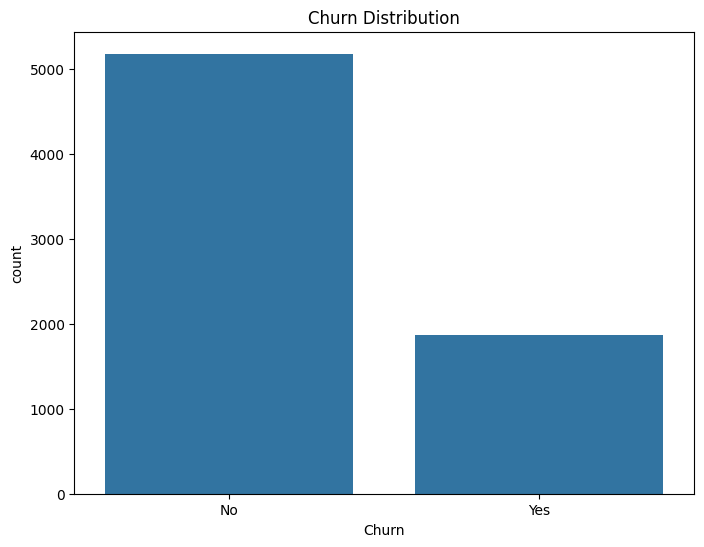

<Figure size 640x480 with 0 Axes>

In [29]:
plt.figure(figsize=(8, 6))
sns.countplot(x=TARGET_COLUMN, data=df)
plt.title('Churn Distribution')
plt.show()
plt.clf()

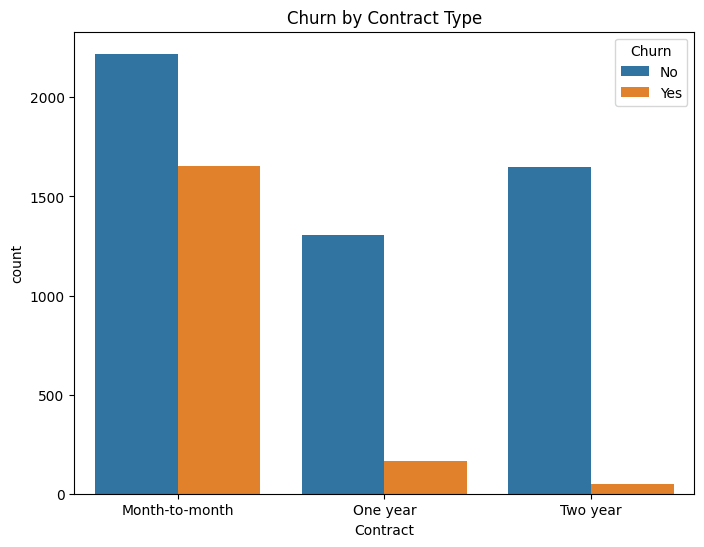

<Figure size 640x480 with 0 Axes>

In [30]:
# Churn by Contract Type
plt.figure(figsize=(8, 6))
sns.countplot(x="Contract", hue=TARGET_COLUMN, data=df)
plt.title("Churn by Contract Type")
plt.show()
plt.clf()

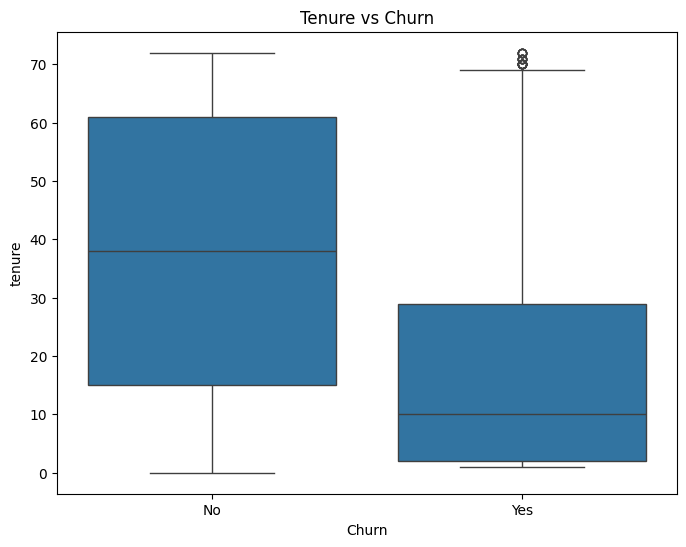

<Figure size 640x480 with 0 Axes>

In [31]:
# Tenure vs Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x=TARGET_COLUMN, y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()
plt.clf()

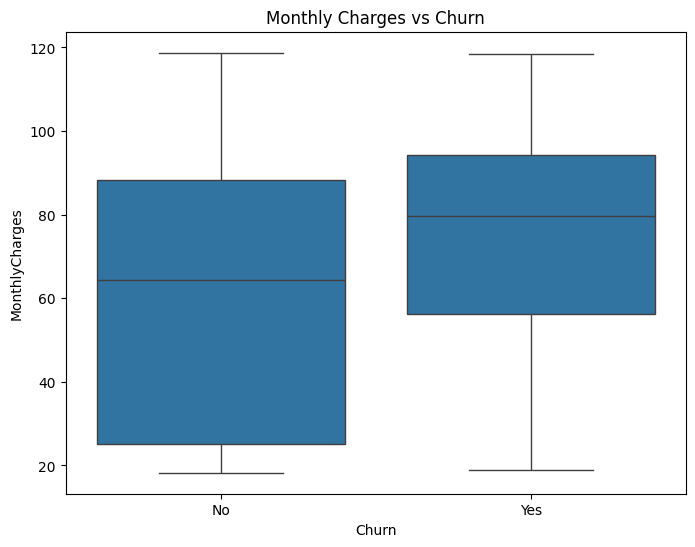

<Figure size 640x480 with 0 Axes>

In [32]:
# Monthly Charges vs Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x=TARGET_COLUMN, y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()
plt.clf()

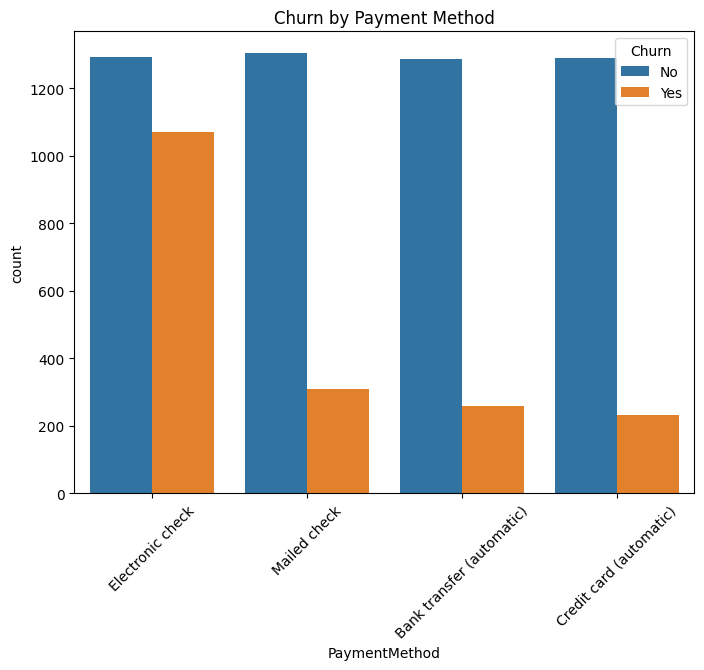

<Figure size 640x480 with 0 Axes>

In [33]:
# Churn by Payment Method
plt.figure(figsize=(8, 6))
sns.countplot(x="PaymentMethod", hue=TARGET_COLUMN, data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()
plt.clf()

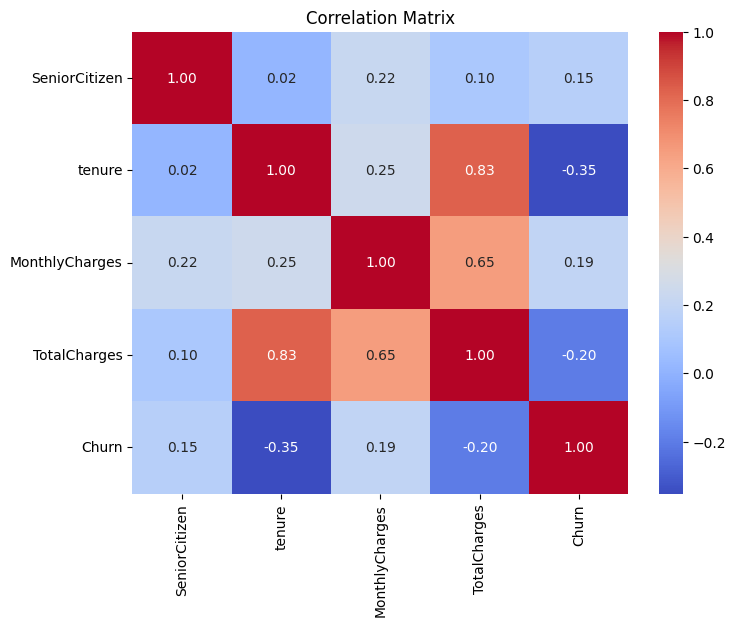

<Figure size 640x480 with 0 Axes>

In [34]:
# Correlation matrix
df[TARGET_COLUMN] = df[TARGET_COLUMN].map({'Yes': 1, 'No': 0})
numeric_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
plt.clf()

<Figure size 1000x800 with 0 Axes>

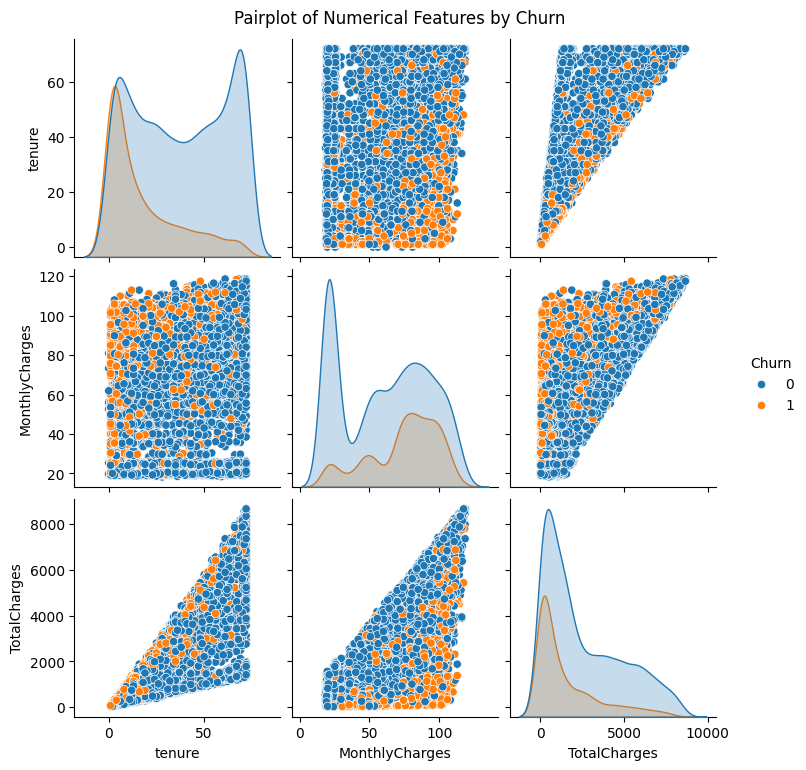

<Figure size 640x480 with 0 Axes>

In [35]:
# Pairplot of numerical features colored by Churn
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue=TARGET_COLUMN, vars=['tenure', 'MonthlyCharges', 'TotalCharges'])
plt.suptitle("Pairplot of Numerical Features by Churn", y=1.02)
plt.show()
plt.clf()

Exploratory Data Analysis was conducted to understand customer churn behavior in the Telco Customer Churn dataset. The target variable, Churn, exhibits class imbalance, with a larger proportion of customers not churning. Analysis revealed that churn rates are significantly higher among customers on month-to-month contracts compared to longer-term contracts. Customers with shorter tenure and higher monthly charges were also more likely to churn, indicating early lifecycle risk and pricing sensitivity. Additionally, payment method showed strong behavioral signals, with electronic check users exhibiting higher churn rates. Inspection of numeric features revealed that TotalCharges had 11 missing values, all corresponding to new customers with very low tenure. The correlation heatmap highlighted moderate relationships, such as negative correlation between tenure and churn, and positive correlation between monthly charges and churn. The pairplot further visualized these trends, showing churners clustering at lower tenure and total charges, reinforcing early churn risk and pricing sensitivity. These findings motivated the use of categorical encoding, feature scaling for numeric variables, handling missing values, and stratified sampling during preprocessing.